# Multiple Linear Regression – Toyota Corolla Price Prediction

Name: Ashar Khan
Batch: Data Science Weekday – Hyderabad  

In this assignment, we analyze a dataset related to Toyota Corolla cars to understand how different factors affect the price. We use multiple linear regression to study the relationship between several input variables such as age, kilometers driven, fuel type, and other features with the car price. The goal is to build a model that can predict the price and explain how each factor contributes to it in a clear and simple manner.

## Importing Required Libraries

In this step, we import all the libraries needed for data analysis, visualization, and machine learning model building. Pandas is used for handling structured data and performing operations on datasets, while NumPy helps in numerical calculations and mathematical operations. Matplotlib and Seaborn are used for creating graphs and visualizations to better understand the data patterns. We also import functions from Scikit-learn for splitting the dataset into training and testing sets, building regression models such as Linear Regression, Ridge, and Lasso, and evaluating model performance using metrics like Mean Squared Error and R² Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset

In this step, we load the dataset containing details of Toyota Corolla cars. The dataset includes variables such as age, kilometers driven, fuel type, horsepower, and price. Loading the dataset allows us to view the data and understand its structure before performing analysis.

In [2]:
df = pd.read_csv(r"/content/ToyotaCorolla - MLR.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset before model building. We use visualizations to study data distributions, identify relationships between variables, and detect patterns or anomalies. This step is important because understanding the dataset helps in selecting relevant features and improves model performance.

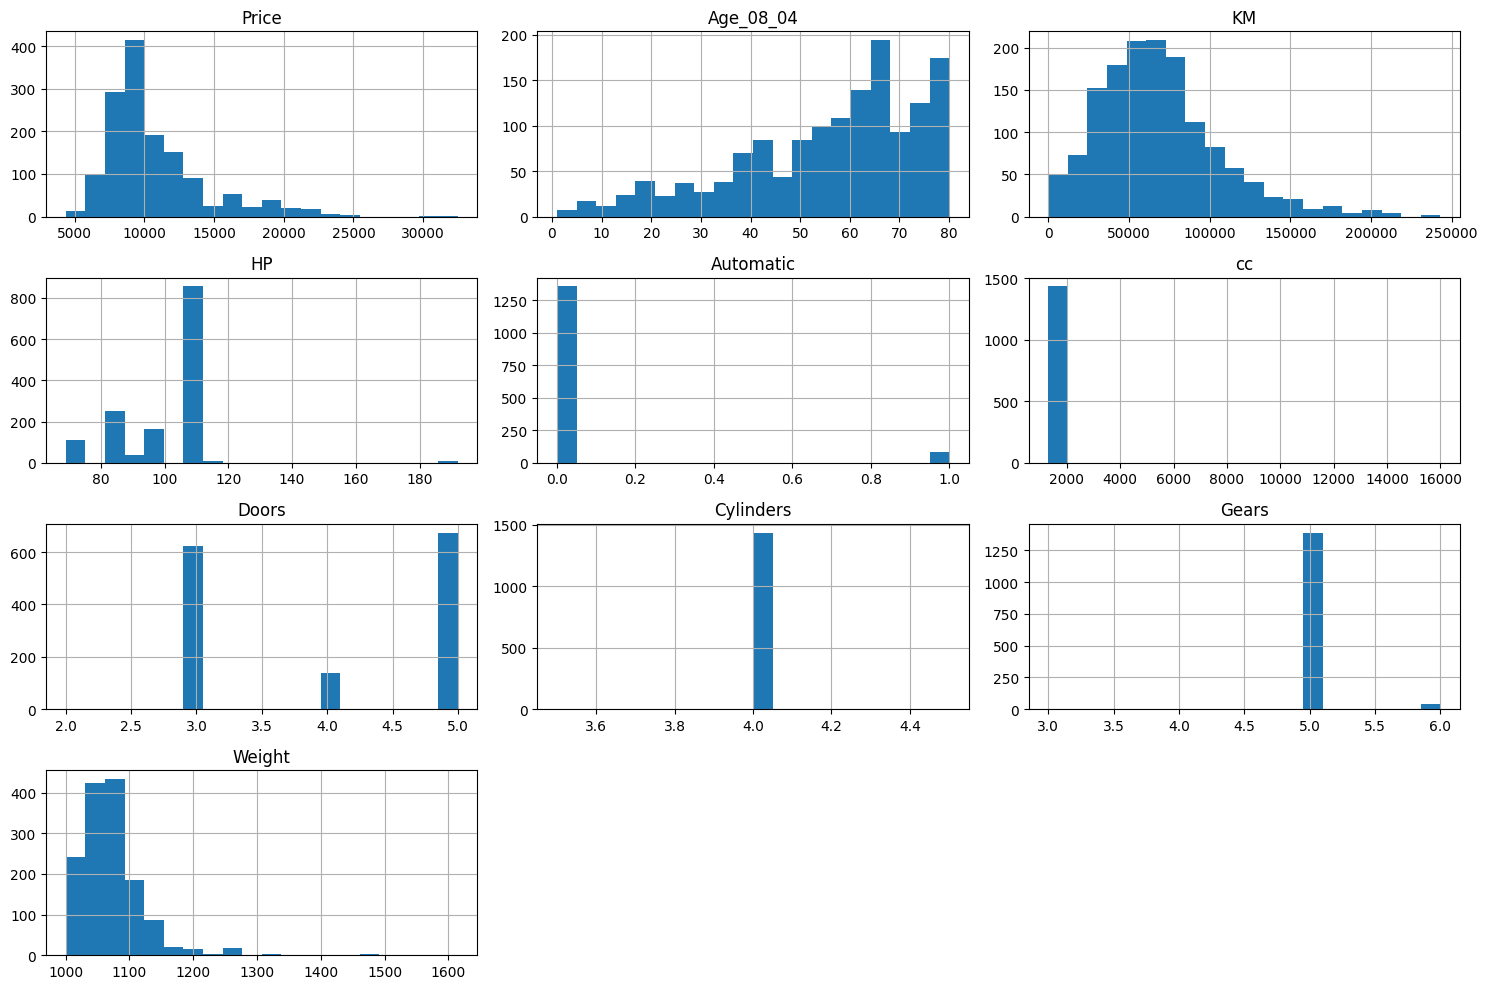

In [3]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

The histograms show the distribution of each numerical variable in the dataset. We can observe how values are spread across different ranges. Some features may appear normally distributed, while others may be skewed. Understanding the distribution helps identify whether transformations or preprocessing steps are needed before model training.

## CORRELATION HEATMAP

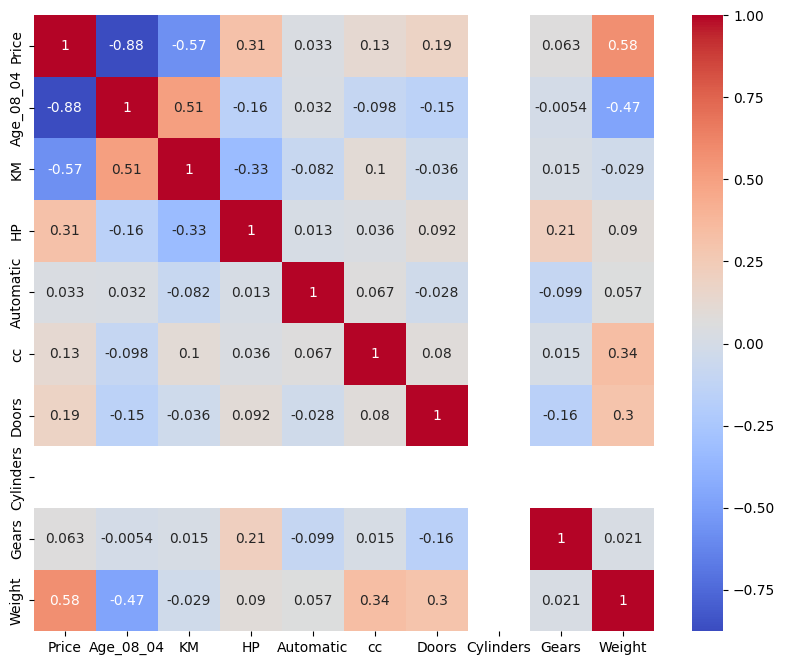

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## SCATTERPLOT

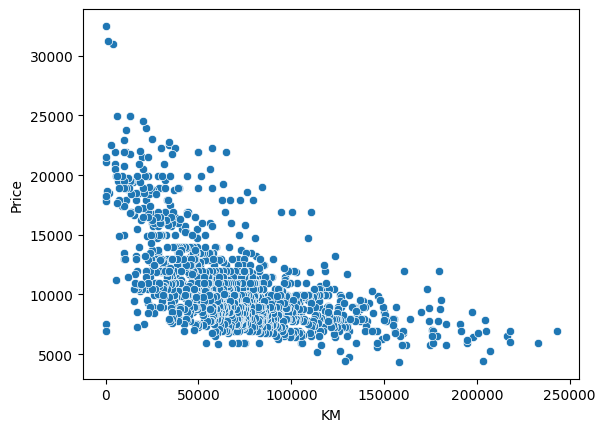

In [5]:
sns.scatterplot(x=df['KM'], y=df['Price'])
plt.show()

The scatterplot shows the relationship between kilometers driven and price. We can observe that as kilometers increase, the price generally decreases. This indicates a negative relationship, which is expected because cars with higher mileage often have lower market value.

## Data Preprocessing

Before building the model, categorical variables need to be converted into numerical format so the regression model can process them. We use one-hot encoding to transform text-based features into machine-readable form.

In [6]:
df = pd.get_dummies(df, drop_first=True)

## Splitting Data

The dataset is split into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate model performance on unseen data.

In [7]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In this step, the dataset is divided into two parts: training data and testing data. The training data is used to build the model, while the testing data is used to evaluate its performance. This ensures that the model is tested on unseen data, which helps in checking its real-world performance.

In [8]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In this step, we build a multiple linear regression model using the training data. The model tries to understand how different features such as age, kilometers driven, and engine capacity affect the price of the car. It assigns a coefficient to each feature, which shows how much that feature influences the price. This model forms the base for comparison with more advanced models.

In [9]:
y_pred1 = model1.predict(X_test)

After training the model, we use it to predict the price using the test data. These predicted values will later be compared with the actual values to check how accurate the model is. This step helps us understand how well the model performs on new data.

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

print("MSE:", mse1)
print("R2 Score:", r2_1)

MSE: 2203043.8231437025
R2 Score: 0.8348888040611082


In this step, we evaluate the performance of the model using two metrics. Mean Squared Error measures how far the predicted values are from the actual values. A smaller value indicates better performance. R-squared shows how well the model explains the data. A value closer to 1 indicates a strong model.

## Coefficient Interpretation

The coefficient table helps us understand how each independent variable affects the target variable. A positive coefficient means that increasing the feature increases the predicted price, while a negative coefficient means that increasing the feature decreases the predicted price. This helps identify the most influential variables in the model.

In [11]:
#INTERPRET COEFFICIENTS (VERY IMPORTANT PART
coeff_df = pd.DataFrame(model1.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Age_08_04,-1.208305e+02
KM,-1.623141e-02
HP,1.403948e+01
Automatic,1.488309e+02
cc,-3.037219e-02
Doors,-6.031097e+01
Cylinders,-1.620037e-12
Gears,5.516007e+02
Weight,2.588496e+01
Fuel_Type_Diesel,-6.854876e+01


INTERPRET COEFFICIENTS (VERY IMPORTANT PART

## Ridge Regression (Model 2)

Ridge Regression is an advanced version of Linear Regression that helps reduce overfitting by adding a penalty term to large coefficient values. This penalty prevents the model from relying too heavily on any one feature and improves generalization on unseen data. Ridge Regression is especially useful when the dataset contains multicollinearity, where independent variables are highly correlated with each other. By controlling coefficient size, Ridge Regression creates a more stable and reliable model.

In [12]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred2 = ridge.predict(X_test)

In this step, we apply Ridge regression, which is an extension of linear regression. Ridge regression helps in reducing overfitting by adding a penalty to large coefficient values. This makes the model more stable and reliable, especially when there are many input variables or when variables are highly related. It improves the model by balancing accuracy and simplicity.

In [13]:
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("Ridge MSE:", mse2)
print("Ridge R2:", r2_2)

Ridge MSE: 2199746.3702333393
Ridge R2: 0.8351359377712336


After applying Ridge regression, we evaluate its performance using the same metrics as before. By comparing these values with the basic linear regression model, we can understand whether Ridge regression improves the model. This step helps us decide if adding regularization makes the predictions more accurate and stable.

## Lasso Regression (Model 3)

Lasso Regression is another variation of Linear Regression that applies regularization to improve model performance. It adds a penalty that can shrink some coefficients completely to zero, effectively removing less important features from the model. This makes Lasso useful for feature selection and helps simplify the model. It is beneficial when the dataset contains many features and we want to identify the most important predictors.

In [14]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred3 = lasso.predict(X_test)

In this step, we apply Lasso regression, which is another type of regularization technique. Lasso not only reduces overfitting but also helps in feature selection by reducing some coefficients to zero. This means it automatically removes less important variables from the model, making it simpler and easier to interpret.

In [15]:
mse3 = mean_squared_error(y_test, y_pred3)
r2_3 = r2_score(y_test, y_pred3)

print("Lasso MSE:", mse3)
print("Lasso R2:", r2_3)

Lasso MSE: 2202270.2600246817
Lasso R2: 0.8349467801805


The performance of the Lasso model is evaluated using mean squared error and R-squared. These values help us understand how well the model is performing compared to other models. If Lasso gives similar or better performance with fewer variables, it is often preferred because it simplifies the model.

In [16]:
print("Linear Regression R2:", r2_1)
print("Ridge Regression R2:", r2_2)
print("Lasso Regression R2:", r2_3)

Linear Regression R2: 0.8348888040611082
Ridge Regression R2: 0.8351359377712336
Lasso Regression R2: 0.8349467801805


The performance of the models is evaluated using two metrics: Mean Squared Error and R-squared. Mean Squared Error measures how far the predicted values are from the actual values, and a smaller value indicates better accuracy. R-squared shows how well the model explains the data, and a value closer to one means the model is performing well.

## Model Comparison

After evaluating all three regression models, we compare their R² scores and Mean Squared Error values to determine which model performs best. The model with the highest R² score and lowest error is considered the most accurate and reliable for prediction. Comparing multiple models helps us identify the most suitable algorithm for the dataset and understand which technique generalizes best on unseen data.

## Difference Between Normalization and Standardization

Normalization scales data between 0 and 1. It is useful when we want all values in a fixed range, especially in distance-based algorithms such as KNN.

Standardization transforms data so that it has a mean of 0 and standard deviation of 1. It is useful when the data follows a normal distribution and is commonly used in regression and classification models.

## Techniques to Address Multicollinearity

Multicollinearity occurs when independent variables are highly correlated with each other. This can reduce model interpretability and performance.

Common techniques to handle multicollinearity include:

1. Removing highly correlated features  
2. Using dimensionality reduction methods such as PCA  
3. Applying Ridge Regression  
4. Combining correlated variables into one feature

## Conclusion

In this assignment, we built and compared three regression models: Linear Regression, Ridge Regression, and Lasso Regression. The dataset was preprocessed, and model performance was evaluated using Mean Squared Error and R² Score. We also interpreted model coefficients to understand feature importance and discussed important machine learning concepts such as normalization, standardization, and multicollinearity. This assignment demonstrates how regression techniques can be used to predict continuous values and compare different algorithms effectively.